In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\baw61\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only get data analyst jobs 
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NaN values from the column for plotting
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

<Axes: >

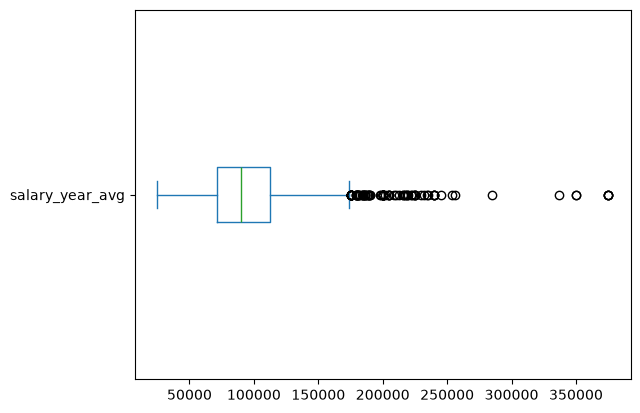

In [6]:
df_DA_US['salary_year_avg'].plot(kind='box', vert=False)

{'whiskers': [<matplotlib.lines.Line2D at 0x26b27fdd510>,
 'caps': [<matplotlib.lines.Line2D at 0x26b27fde6d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x26b0e4c47d0>],
 'medians': [<matplotlib.lines.Line2D at 0x26b27fd2350>],
 'fliers': [<matplotlib.lines.Line2D at 0x26b27fdfb50>],
 'means': []}

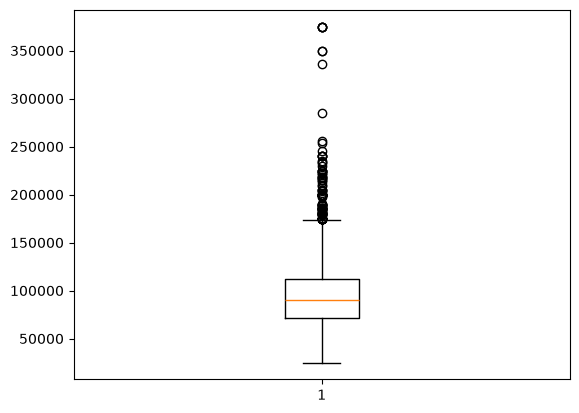

In [5]:
plt.boxplot(df_DA_US['salary_year_avg'])

C:\Users\baw61\AppData\Local\Temp\ipykernel_9348\2616308721.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False)


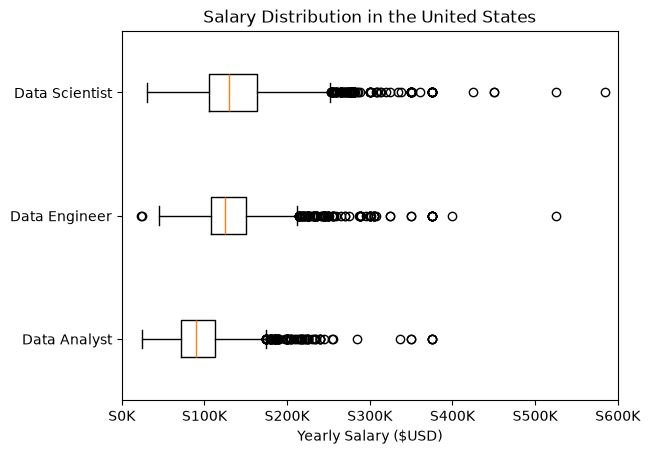

In [19]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

df_US = df_US.dropna(subset=['salary_year_avg'])

job_list = [df_US[df_US['job_title_short'] == job_title] ['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'S{int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

In [11]:
job_list[0]

109        89000.0
180        90250.0
410       133285.0
988        62623.0
1413       71300.0
            ...   
782637     70000.0
782798    111175.0
783588    125000.0
783866    115000.0
784882     87500.0
Name: salary_year_avg, Length: 4350, dtype: float64

In [22]:
df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset=['salary_hour_avg'])

<Axes: >

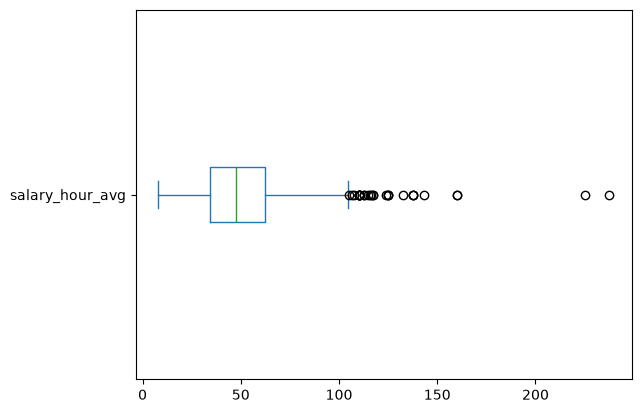

In [23]:
df_DS_US['salary_hour_avg'].plot(kind='box', vert=False)

In [24]:
countries = ['United States', 'Canada']

In [31]:
df_DA = df[(df['job_country'].isin(countries)) & (df['job_title_short'] == 'Data Analyst')].copy()

df_DA = df_DA.dropna(subset=['salary_hour_avg'])

country_list = [df_DA[df_DA['job_country'] == country] ['salary_hour_avg'] for country in countries]


C:\Users\baw61\AppData\Local\Temp\ipykernel_9348\3470955806.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(country_list, tick_labels=countries, vert=False)


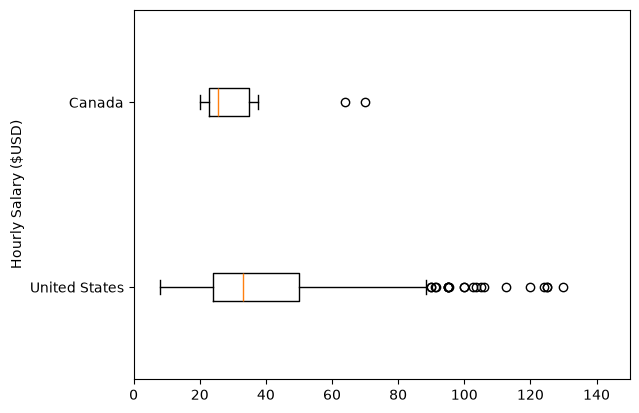

In [34]:
plt.boxplot(country_list, tick_labels=countries, vert=False)
plt.xlim(0, 150)
plt.ylabel('Hourly Salary ($USD)')
plt.show()

In [35]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

In [36]:
df_canada = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'Canada')].copy()

In [37]:
df_canada = df_canada.dropna(subset=['salary_hour_avg'])

In [39]:
job_list = [df_canada[df_canada['job_title_short'] == job_title] ['salary_hour_avg'] for job_title in job_titles]

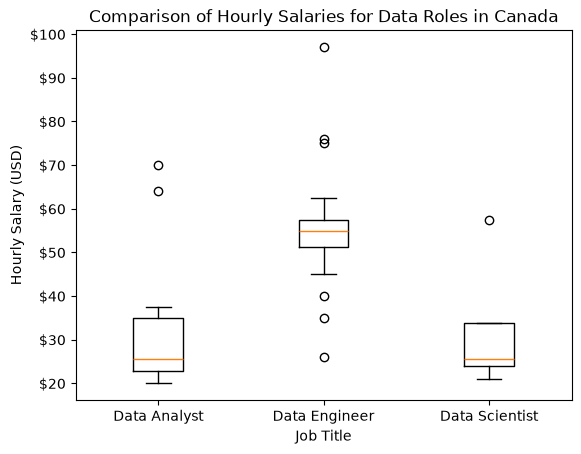

In [44]:
fig, ax = plt.subplots()
ax.boxplot(job_list, tick_labels=job_titles)
ax.set_xlabel('Job Title')
ax.set_ylabel('Hourly Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, post: f'${int(y)}'))
ax.set_title('Comparison of Hourly Salaries for Data Roles in Canada')
plt.show()
